In [9]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import numpy as np

data = load_breast_cancer()
X = data.data
y = data.target

print("classes:", data.target_names)
print("features:", data.feature_names[:5])

classes: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


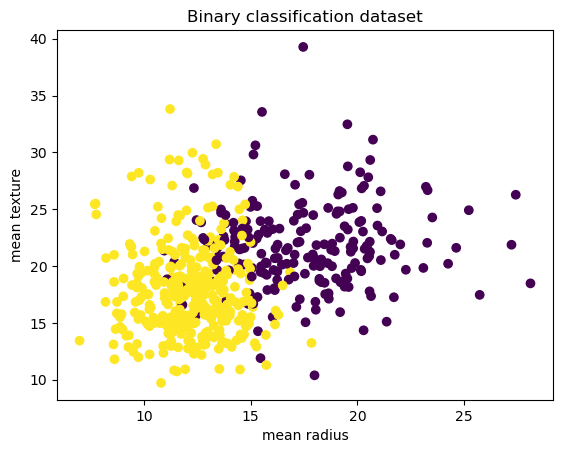

In [11]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Binary classification dataset")
plt.show()

# Class Tree

In [ ]:
import numpy as np

class DecisionTree:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.tree = None

    # Entropie
    def entropy(self, y):
        m = len(y)
        _, counts = np.unique(y, return_counts=True)
        p = counts / m
        return -np.sum(p * np.log2(p + 1e-15))

    # Information Gain
    def information_gain(self, X_column, y, threshold):
        # split
        left_idx = X_column <= threshold
        right_idx = X_column > threshold

        y_left = y[left_idx]
        y_right = y[right_idx]

        if len(y_left) == 0 or len(y_right) == 0:
            return 0

        # entropie
        H_before = self.entropy(y)

        H_left = self.entropy(y_left)
        H_right = self.entropy(y_right)

        m = len(y)
        H_after = (len(y_left)/m)*H_left + (len(y_right)/m)*H_right

        return H_before - H_after

    # Trouver meilleur split
    def best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        n_features = X.shape[1]

        for feature in range(n_features):
            values = np.unique(X[:, feature])

            for threshold in values:
                gain = self.information_gain(X[:, feature], y, threshold)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    # Construire l'arbre
    def build_tree(self, X, y, depth=0):
        # condition arrêt
        if len(np.unique(y)) == 1 or depth == self.max_depth:
            return self.majority_class(y)

        feature, threshold = self.best_split(X, y)

        if feature is None:
            return self.majority_class(y)

        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        left = self.build_tree(X[left_idx], y[left_idx], depth+1)
        right = self.build_tree(X[right_idx], y[right_idx], depth+1)

        return {
            "feature": feature,
            "threshold": threshold,
            "left": left,
            "right": right
        }

    # Classe majoritaire
    def majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    #Entraînement
    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    # Prédire un seul exemple
    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node

        if x[node["feature"]] <= node["threshold"]:
            return self.predict_one(x, node["left"])
        else:
            return self.predict_one(x, node["right"])

    # Prédiction
    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])